In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%reload_ext autoreload
import time, os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from models.network import HCNet
from models.utils.utils import get_homograpy
from models.utils.loss_factory import zod_se2_loss
import dataset as datasets
import json
from easydict import EasyDict
import argparse
import shlex


from models.utils.utils import *
from models.utils.loss_factory import *


In [43]:
args_str = "--iters_lev0 6 --CNN16 --flow --batch_size 32 --p_siamese --ori_noise 45 --restore_ckpt checkpoints/best_checkpoint_zod.pth"
# checkpoints/2025_12_17_best_checkpoint_zod_0.pth
parser = argparse.ArgumentParser()
parser.add_argument('--config', type=str, default="models/config/ZOD/train.json")
parser.add_argument('--dropout', type=float, default=0.0)
parser.add_argument('--start_step', type=int, default=0)
parser.add_argument('--batch_size', type=int, default=None)
parser.add_argument('--name', default='HC-Net')
parser.add_argument('--restore_ckpt', type=str, default=None)
parser.add_argument('--validation', type=str, nargs='+', default=None)
parser.add_argument('--best_dis', type=float, default=1e8)

# add the flags you want to accept
parser.add_argument('--iters_lev0', type=int, default=6)
parser.add_argument('--ori_noise', type=float, default=45.0)
parser.add_argument('--CNN16', action='store_true')
parser.add_argument('--flow', action='store_true')
parser.add_argument('--p_siamese', action='store_true')

args = parser.parse_args(shlex.split(args_str))  # key line [web:462][web:479]
print(args)


config = json.load(open("models/config/ZOD/train.json",'r'))
config = EasyDict(config)
config['config'] = "models/config/ZOD/train.json"
config['best_dis'] = 1e8
config['validation'] = args.validation
config['name'] = args.name
config['restore_ckpt'] = args.restore_ckpt
config['start_step'] = args.start_step
if args.batch_size: 
    config['batch_size'] = args.batch_size

print(config)

setup_seed(2023)
print_colored(time.strftime('%Y-%m-%d %H:%M:%S',time.localtime(time.time())))

if not os.path.isdir('checkpoints'):
    os.mkdir('checkpoints')
if config.dataset=='vigor':
    print("Dataset is VIGOR!")  


Namespace(config='models/config/ZOD/train.json', dropout=0.0, start_step=0, batch_size=32, name='HC-Net', restore_ckpt='checkpoints/best_checkpoint_zod.pth', validation=None, best_dis=100000000.0, iters_lev0=6, ori_noise=45.0, CNN16=True, flow=True, p_siamese=True)
{'gpuid': [0], 'mixed_precision': False, 'iters_lev0': 6, 'lev0': True, 'flow': True, 'p_siamese': True, 'CNN16': True, 'dataset': 'zod', 'orig_label': False, 'cross_area': False, 'batch_size': 32, 'lr': 0.00035, 'num_steps': 190252, 'scheduler': 'OneCycle', 'loss_w': [0.1, 1.0, 10.0], 'temperature': 4.0, 'augment': False, 'ori_noise': 45.0, 'orien': True, 'restore_ckpt': 'checkpoints/best_checkpoint_zod.pth', 'model': None, 'wdecay': 0.0005, 'epsilon': 1e-07, 'clip': 1.0, 'gamma': 0.85, 'name': 'HC-Net', 'validation': None, 'image_size': 512, 'zoom': 20, 'IMG_FREQ': 20000, 'SUM_FREQ': 100, 'use_augmentation': True, 'image_area_dg_m': 51.2, 'image_area_zod_m': 100, 'max_translation': 15.0, 'max_rot_deg': 20.0, 'z_range': [-2

In [44]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
args = config
args.gpuid = [0]          # pick GPU id you want
model = HCNet(args).to(device)
ckpt = torch.load(args.restore_ckpt, map_location=device)
state = ckpt.get("model", ckpt)
state = { (k[7:] if k.startswith("module.") else k): v for k,v in state.items() }
model.load_state_dict(state, strict=False)
model.eval()


Loaded pretrained weights for efficientnet-b0


/tmp/2754349/ipykernel_4029253/4240677133.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(args.restore_ckpt, map_location=device)


HCNet(
  (sat_efficientnet): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStaticSamePadd

In [45]:
%reload_ext autoreload
from torch.utils.data import DataLoader
import dataset.ZOD as datasets


# Use your dataset
val_dataset = datasets.fetch_dataloader(args, split="val")

# inspection collate (keeps points as a list)
def zod_collate_inspect(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    out = {}
    for k in ["image","bev_lidar","rotation","translation","resolution"]:
        out[k] = torch.stack([s[k] for s in batch], 0)
    out["points"] = [s["points"] for s in batch]  # variable length
    return out

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True,
                        num_workers=0, pin_memory=False,
                        collate_fn=zod_collate_inspect)


Loading infos: 0it [00:00, ?it/s]

Loading val split : 6 drives
Validation with 62 samples.


In [55]:
batch = next(iter(val_loader))
batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k,v in batch.items()}

sat_img = batch["image"]
bev = batch["bev_lidar"]
rot_gt = batch["rotation"]
trans_gt = batch["translation"]
resolution = batch["resolution"]
points = batch["points"][0].to(device)  # (N,3)

with torch.no_grad():
    four_pred, corr_fn = model(bev, sat_img, sat_gps=None, iters_lev0=args.iters_lev0)
#trans_gt = torch.tensor([[trans_gt[:,0], -trans_gt[:,1]]], device = trans_gt.device)
loss, m = zod_se2_loss(four_pred, sat_img, rot_gt, trans_gt, resolution, gamma=args.gamma)
print("loss:", float(loss))
print("metrics:", m)


loss: 1.2552145719528198
metrics: {'trans_l2_m': 0.16370204091072083, 'trans_abs_dx_m': 0.03891468048095703, 'trans_abs_dy_m': 0.15900945663452148, 'pred_dx_m': -8.275816917419434, 'pred_dy_m': 4.792938232421875, 'gt_dx_m': -8.236902236938477, 'gt_dy_m': 4.9519476890563965, 'yaw_err_deg': 7.217376708984375, 'pred_yaw_deg': -0.7579175233840942, 'gt_yaw_deg': -7.9752936363220215}


[-8.27581692  4.79293823]


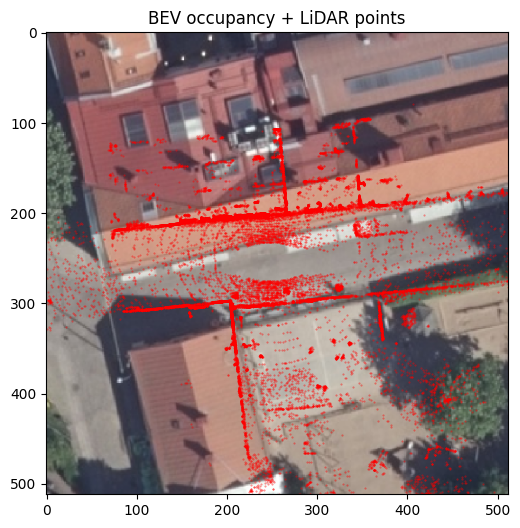

In [56]:
# args.image_area_dg_m = 51.2  # must match your dataset/BEV

bev0 = bev[0].detach().cpu().float().numpy()   # (C,Hb,Wb)
occ = bev0[:-1].max(axis=0)                   # (Hb,Wb)
img = sat_img.detach().cpu().float().permute([0,2,3,1]).numpy()[0,:,:,:]


Hb, Wb = occ.shape
pts = points.detach().cpu().float().numpy()[:,:2]
theta = np.radians(m["pred_yaw_deg"]) 
rot = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
trans = np.array([m["pred_dx_m"], m["pred_dy_m"]])
print(trans, )


#rot = rot_gt.detach().cpu().float().numpy()[0,:2,:2]
#trans = trans_gt.detach().cpu().float().numpy()[0,:2]
# ((data["points"] - data["translation"]) @ np.linalg.inv(data["rotation"].T) )/s


pts_rot = (pts - trans)@np.linalg.inv(rot.T) / resolution.detach().cpu().float()
x, y = pts_rot[:,0], pts_rot[:,1]

H_img, W_img, _ = img.shape
x = W_img//2 + x 
y = H_img//2 - y


mask = (x >= 0) & (x < W_img) & (y >= 0) & (y < H_img)

plt.figure(figsize=(6,6))
#plt.imshow(occ, origin='lower', cmap='gray')   # [web:275][web:444]
plt.scatter(x[mask], y[mask], s=0.2, c='r', alpha=0.5)
plt.imshow(img, origin='upper')
plt.title("BEV occupancy + LiDAR points")
plt.gca().set_aspect('equal')
plt.show()


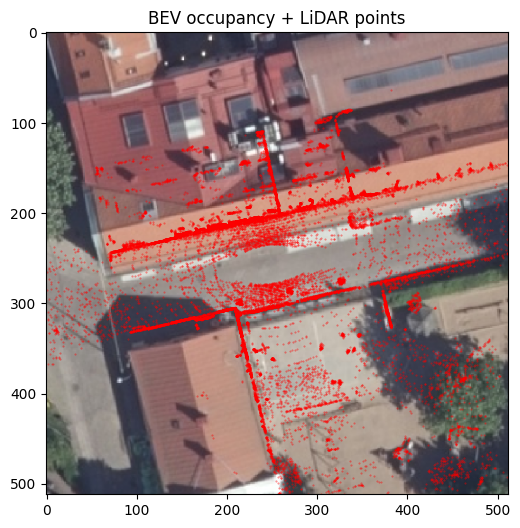

In [57]:

rot = rot_gt.detach().cpu().float().numpy()[0,:2,:2]
trans = trans_gt.detach().cpu().float().numpy()[0,:2]
# ((data["points"] - data["translation"]) @ np.linalg.inv(data["rotation"].T) )/s


pts_rot = (pts - trans)@np.linalg.inv(rot.T) / resolution.detach().cpu().float()
x, y = pts_rot[:,0], pts_rot[:,1]

H_img, W_img, _ = img.shape
x = W_img//2 + x 
y = H_img//2 - y


mask = (x >= 0) & (x < W_img) & (y >= 0) & (y < H_img)

plt.figure(figsize=(6,6))
#plt.imshow(occ, origin='lower', cmap='gray')   # [web:275][web:444]
plt.scatter(x[mask], y[mask], s=0.2, c='r', alpha=0.5)
plt.imshow(img, origin='upper')
plt.title("BEV occupancy + LiDAR points")
plt.gca().set_aspect('equal')
plt.show()


In [58]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def warp_bev_to_sat_like_points(bev_occ, rot, trans, resolution, out_H, out_W, area_m):
    """
    Warp BEV occupancy (B,1,Hb,Wb) into satellite pixel grid (B,1,out_H,out_W)
    using the SAME convention as your point overlay snippet.

    rot: (B,3,3)  data["rotation"]
    trans: (B,3)  data["translation"]
    resolution: (B,) meters per pixel (your s)
    area_m: float BEV covers [-area_m/2, area_m/2] in meters for both x,y
    """
    device = bev_occ.device
    B, _, Hb, Wb = bev_occ.shape
    cx = (out_W - 1) / 2.0
    cy = (out_H - 1) / 2.0

    # Output pixel grid (u,v)
    u = torch.linspace(0, out_W - 1, out_W, device=device)
    v = torch.linspace(0, out_H - 1, out_H, device=device)
    vv, uu = torch.meshgrid(v, u, indexing="ij")  # (H,W)

    uu = uu.unsqueeze(0).repeat(B, 1, 1)  # (B,H,W)
    vv = vv.unsqueeze(0).repeat(B, 1, 1)

    res = resolution.view(B, 1, 1)

    # Convert output pixels -> "point coords" in meters that your overlay expects AFTER undoing pose:
    # your plot uses:
    #   x_pix = cx + x_m/res
    #   y_pix = cy - y_m/res
    # so invert:
    x_m = (uu - cx) * res
    y_m = (cy - vv) * res   # note the sign, matches your snippet

    # Now invert your point transform:
    # snippet: p_m = ( (p - t) @ inv(R^T) )
    # So to find p that maps to (x_m,y_m): solve for p:
    #   p - t = p_m @ R^T   (because inv(R^T) inverted)
    #   p = p_m @ R^T + t
    try : 
        R = rot[:, 0:2, 0:2]                 # (B,2,2)
        t = trans[:, 0:2].view(B, 1, 1, 2)   # (B,1,1,2)
    except:
        R = rot
        t = trans

    # p_m stacked last dim
    p_m = torch.stack([x_m, y_m], dim=-1)          # (B,H,W,2)
    try:
        p = torch.einsum('bhwk,bkj->bhwj', p_m, R.transpose(1, 2)) + t  # (B,H,W,2)
    except:
        R = R.to(device)
        p_m = p_m.to(device)
        t = t.to(device)
        p = torch.einsum('hwk,kj->hwj', p_m.squeeze(), R.T) + t  # (B,H,W,2)
        p = p.unsqueeze(0)
    # Map p (meters in BEV frame) to BEV pixel coords
    A = area_m
    x = p[..., 0]
    y = p[..., 1]
    x_min, x_max = -A/2, A/2
    y_min, y_max = -A/2, A/2

    u_bev = (x - x_min) / (x_max - x_min) * (Wb - 1)
    v_bev = (y - y_min) / (y_max - y_min) * (Hb - 1)

    # Normalize for grid_sample: (x_norm,y_norm) in [-1,1]
    x_norm = 2.0 * (u_bev / (Wb - 1)) - 1.0
    y_norm = 2.0 * (v_bev / (Hb - 1)) - 1.0
    grid = torch.stack([x_norm, y_norm], dim=-1)  # (B,out_H,out_W,2)

    # Sample BEV into satellite grid
    bev_warp = F.grid_sample(bev_occ, grid, mode="bilinear",
                             padding_mode="zeros", align_corners=True)
    return bev_warp  # (B,1,out_H,out_W)


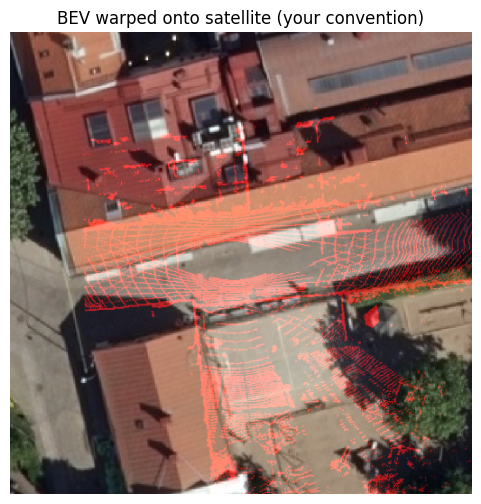

In [59]:
theta = np.radians(m["pred_yaw_deg"]) 
rot = torch.Tensor([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])
trans = torch.Tensor([m["pred_dx_m"], m["pred_dy_m"]])

# sat_img: (B,3,H,W), bev: (B,C,Hb,Wb)
B, _, H, W = sat_img.shape

# occupancy from BEV
occ = bev[:, :-1].amax(dim=1, keepdim=True)  # (B,1,Hb,Wb)

# occ_warp = warp_bev_to_sat_like_points(occ, rot_gt, trans_gt, resolution, out_H=H, out_W=W, area_m=args.image_area_dg_m)
occ_warp = warp_bev_to_sat_like_points(occ, rot, trans, resolution, out_H=H, out_W=W, area_m=args.image_area_dg_m)

# normalize for display
sat = sat_img
sat_disp = (sat - sat.amin(dim=(2,3), keepdim=True)) / (sat.amax(dim=(2,3), keepdim=True) - sat.amin(dim=(2,3), keepdim=True) + 1e-6)
ow = (occ_warp - occ_warp.amin(dim=(2,3), keepdim=True)) / (occ_warp.amax(dim=(2,3), keepdim=True) - occ_warp.amin(dim=(2,3), keepdim=True) + 1e-6)

overlay = sat_disp.clone()
overlay[:, 0] = torch.clamp(overlay[:, 0] + 0.6 * ow[:, 0], 0, 1)  # add red heat

img = overlay[0].detach().cpu().permute(1,2,0).numpy()
plt.figure(figsize=(6,6))
plt.imshow(img, origin="upper")
plt.title("BEV warped onto satellite (your convention)")
plt.axis("off")
plt.show()


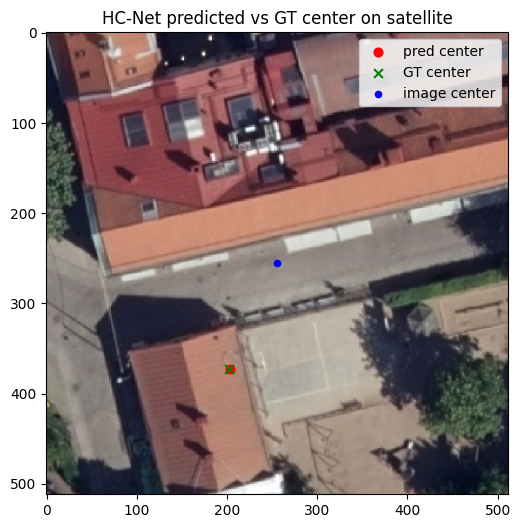

In [60]:
# prepare image for plotting
img_np = sat_img[0].detach().cpu().numpy()  # (3,H,W)
img_np = np.transpose(img_np, (1,2,0))      # (H,W,3)

# convert any normalization back to [0,1] if needed
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-6)

plt.figure(figsize=(6,6))
plt.imshow(img_np, origin='upper')

# plot predicted center (red) and GT center (green)
px, py = x_pred[0].detach().cpu().numpy()
gx, gy = x_gt[0].detach().cpu().numpy()

plt.scatter([px], [py], c='r', s=40, label='pred center')
plt.scatter([gx], [gy], c='g', s=40, marker='x', label='GT center')

# also mark image center
plt.scatter([cx], [cy], c='b', s=20, label='image center')

plt.legend()
plt.gca().set_aspect('equal')
plt.title("HC-Net predicted vs GT center on satellite")
plt.show()


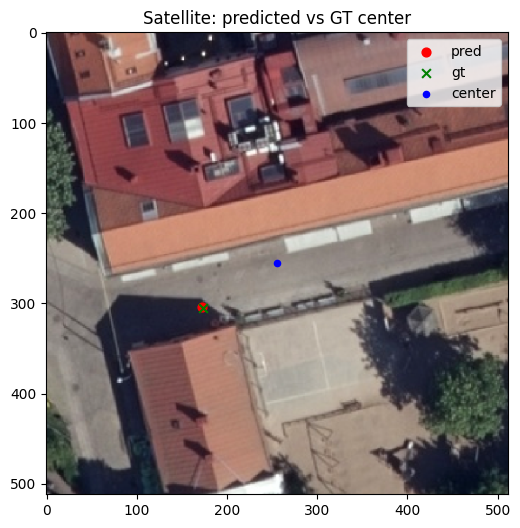

In [61]:
B, _, H, W = sat_img.shape
sz = [B,1,H,W]
four_last = four_pred[-1] if isinstance(four_pred, list) else four_pred
H_mat = get_homograpy(four_last, sz)

cx = (W - 1)/2
cy = (H - 1)/2

pts_center = torch.tensor([[[cx],[cy],[1.0]]], dtype=torch.float32, device=device)
x = H_mat.bmm(pts_center); x = x / x[:,2:3,:]
x_pred = x[:,0:2,0]

# GT pixel
res_ = resolution.view(B,1)
cos_t = rot_gt[:,0,0].view(B,1)
sin_t = rot_gt[:,1,0].view(B,1)
dx = trans_gt[:,0].view(B,1)
dy = trans_gt[:,1].view(B,1)
x_gt = torch.cat([dx/res_ + cx, dy/res_ + cy], dim=1)

img = sat_img[0].detach().cpu().float().numpy()
img = np.transpose(img, (1,2,0))
img = (img - img.min()) / (img.max()-img.min()+1e-6)

plt.figure(figsize=(6,6))
plt.imshow(img, origin='upper')
plt.scatter([x_pred[0,0].item()], [x_pred[0,1].item()], c='r', s=40, label='pred')
plt.scatter([x_gt[0,0].item()], [x_gt[0,1].item()], c='g', s=40, marker='x', label='gt')
plt.scatter([cx],[cy], c='b', s=20, label='center')
plt.legend()
plt.title("Satellite: predicted vs GT center")
plt.show()


In [18]:

w1, w2, w3 = args.loss_w

loss_homo, metrics = zod_homo_loss(four_pred, sat_img,rot_gt=rot_gt, trans_gt=trans_gt, resolution=resolution,gamma=args.gamma)

_, supervision_zod_RTE = zod_se2_loss(four_pred, sat_img,rot_gt=rot_gt,trans_gt=trans_gt, resolution=resolution, gamma=args.gamma,)

infoLoss = InfoNCELoss(temperature=args.temperature)

loss_h, metrics = zod_homo_loss_original_style(four_pred, sat_img,rot_gt=rot_gt,trans_gt=trans_gt,resolution=resolution,sat_size=args.sat_size,gamma=args.gamma,orien=True,w_ori=w3,)

# corr_fn: depends on your model; you might need corr_fn.corr_pyramid[0]
corr_tensor = corr_fn.corr_pyramid[0] if hasattr(corr_fn, "corr_pyramid") else corr_fn
#loss_c = corr_loss_zod(corr_tensor, infoLoss, )

loss = loss_h * w1 + loss_c * w2

print(loss.cpu().item(), loss_h.cpu().item(), loss_c.cpu().item(), supervision_zod_RTE["trans_l2_m"], supervision_zod_RTE["yaw_err_deg"])


NameError: name 'zod_homo_loss_original_style' is not defined

In [ ]:
loss_homo, loss_h

In [ ]:
loss_h, metrics = zod_homographic_loss_with_ori(
    four_pred, sat_img,
    rot_gt=rot_gt,
    trans_gt=trans_gt,
    resolution=resolution,
    gamma=args.gamma,
    orien=True,
    w_ori=w3,          # reuse your w3
)


In [ ]:
loss_h, metrics


In [24]:
from models.utils.loss_factory import *
loss1, metrics, y = zod_like_vigor_gps_loss(four_pred,sat_img,rot_gt=rot_gt,trans_gt=trans_gt,resolution=resolution, args=args, w3 = w3, orien = True,gamma=args.gamma)
loss2 = corr_loss_zod(corr_fn, infoLoss, y, sz = [sat_img.shape[2],sat_img.shape[3]])

loss = loss*w1 + loss2*w2

tensor(14475.6025, device='cuda:0')
tensor(14842.2559, device='cuda:0')
tensor(14785.3428, device='cuda:0')
tensor(14645.3105, device='cuda:0')
tensor(14504.6514, device='cuda:0')
tensor(14382.2295, device='cuda:0')


In [62]:
_, supervision_zod_RTE = zod_se2_loss(four_pred, sat_img,rot_gt=rot_gt,trans_gt=trans_gt, resolution=resolution, gamma=args.gamma,)


In [63]:
supervision_zod_RTE

{'trans_l2_m': 0.16370204091072083,
 'trans_abs_dx_m': 0.03891468048095703,
 'trans_abs_dy_m': 0.15900945663452148,
 'pred_dx_m': -8.275816917419434,
 'pred_dy_m': 4.792938232421875,
 'gt_dx_m': -8.236902236938477,
 'gt_dy_m': 4.9519476890563965,
 'yaw_err_deg': 7.217376708984375,
 'pred_yaw_deg': -0.7579175233840942,
 'gt_yaw_deg': -7.9752936363220215}

In [64]:
loss1, m, y = zod_homo_loss_test(four_pred, sat_img, rot_gt, trans_gt, resolution, w3=w3, orien=True, gamma=args.gamma)
loss2 = corr_loss_zod(corr_fn, infoLoss, y, sz = [sat_img.shape[2],sat_img.shape[3]])

loss = loss1*w1 + loss2*w2

In [65]:
loss, loss1, loss2, m

(tensor(103.4120, device='cuda:0'),
 tensor(302.0406, device='cuda:0'),
 tensor(73.2080, device='cuda:0'),
 {'pix_l2': 1.6370134353637695,
  'pred_x_pix': 172.74183654785156,
  'pred_y_pix': 303.42938232421875,
  'trans_l2_m': 0.16370204091072083,
  'trans_abs_dx_m': 0.03891468048095703,
  'trans_abs_dy_m': 0.15900945663452148,
  'pred_dx_m': -8.275816917419434,
  'pred_dy_m': 4.792938232421875,
  'gt_dx_m': -8.236902236938477,
  'gt_dy_m': 4.9519476890563965,
  'yaw_err_deg': 7.217376708984375,
  'pred_yaw_deg': -0.7579175233840942,
  'gt_yaw_deg': -7.9752936363220215})